# GFS forecasts for a lake case, as an xarray dataset 

## Actually, 2 datasets. 

### Part 1: analysis (83002) or short leads (0,3,6,9H - 83003, from 2015 July) in year-by-year aggregations

https://tds.gdex.ucar.edu/thredds/catalog/catalog.html

xr.open_dataset('https://tds.gdex.ucar.edu/thredds/dodsC/aggregations/g/d083002/2/d083002_Grib2-2015')

xr.open_dataset('https://tds.gdex.ucar.edu/thredds/dodsC/aggregations/g/d083003/1/d083003-2015')

### Part 2 for longer lead forecasts, this must be constructed from a file by file archive

https://tds.gdex.ucar.edu/thredds/catalog/catalog_d084001.html. 

Eventually I mistrusted UM Copilot and **switched to Claude. Is it better? YES, much faster**. 


In [125]:
# Claude says start with this up top, once and for all 

import multiprocessing
multiprocessing.set_start_method("fork", force=True)  # macOS/Linux only

import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Part 1: analysis and 3-6-9h leads, an aggregation

In [97]:
import xarray as xr 

# gfs_agg = xr.open_dataset('https://tds.gdex.ucar.edu/thredds/dodsC/aggregations/g/d083003/1/d083003-2015') from July 2015 only
gfs_agg = xr.open_dataset('https://tds.gdex.ucar.edu/thredds/dodsC/aggregations/g/d083002/2/d083002_Grib2-2015')
gfs_agg

<xarray.Dataset> Size: 126GB
Dimensions:                                                                   (
                                                                               lat: 181,
                                                                               lon: 360,
                                                                               time: 1407,
                                                                               time1: 53,
                                                                               time2: 1460,
                                                                               ...
                                                                               height_above_ground_layer_bounds_1: 2,
                                                                               height_above_ground_layer1_bounds_1: 2,
                                                                               pressure_difference_layer1_bounds_1: 2,
                                                                               sigma_layer_bounds_1: 2,
                                                                               depth_below_surface_layer_bounds_1: 2,
                                                                               pressure_difference_layer2_bounds_1: 2)
Coordinates: (12/28)
  * lat                                                                       (lat) float32 724B ...
  * lon                                                                       (lon) float32 1kB ...
  * time                                                                      (time) datetime64[ns] 11kB ...
    reftime                                                                   (time) datetime64[ns] 11kB ...
  * time1                                                                     (time1) datetime64[ns] 424B ...
    reftime1                                                                  (time1) datetime64[ns] 424B ...
    ...                                                                        ...
  * height_above_ground2                                                      (height_above_ground2) float32 4B ...
  * height_above_ground3                                                      (height_above_ground3) float32 8B ...
  * potential_vorticity_surface                                               (potential_vorticity_surface) float32 8B ...
  * pressure_difference_layer2                                                (pressure_difference_layer2) float32 8B ...
  * sigma                                                                     (sigma) float32 4B ...
  * height_above_ground4                                                      (height_above_ground4) float32 12B ...
Dimensions without coordinates: pressure_difference_layer_bounds_1,
                                height_above_ground_layer_bounds_1,
                                height_above_ground_layer1_bounds_1,
                                pressure_difference_layer1_bounds_1,
                                sigma_layer_bounds_1,
                                depth_below_surface_layer_bounds_1,
                                pressure_difference_layer2_bounds_1
Data variables: (12/105)
    LatLon_Projection                                                         int32 4B ...
    pressure_difference_layer_bounds                                          (pressure_difference_layer, pressure_difference_layer_bounds_1) float32 8B ...
    height_above_ground_layer_bounds                                          (height_above_ground_layer, height_above_ground_layer_bounds_1) float32 8B ...
    height_above_ground_layer1_bounds                                         (height_above_ground_layer1, height_above_ground_layer1_bounds_1) float32 8B ...
    pressure_difference_layer1_bounds                                         (pressure_difference_layer1, pressure_difference_layer1_bounds_1) float32 8B ...
    sigma_

In [98]:
list(gfs_agg.data_vars)

['LatLon_Projection',
 'pressure_difference_layer_bounds',
 'height_above_ground_layer_bounds',
 'height_above_ground_layer1_bounds',
 'pressure_difference_layer1_bounds',
 'sigma_layer_bounds',
 'depth_below_surface_layer_bounds',
 'pressure_difference_layer2_bounds',
 'Absolute_vorticity_isobaric',
 'Apparent_temperature_height_above_ground',
 'Cloud_mixing_ratio_isobaric',
 'Cloud_water_entire_atmosphere_single_layer',
 'Convective_available_potential_energy_surface',
 'Convective_available_potential_energy_pressure_difference_layer',
 'Convective_inhibition_surface',
 'Convective_inhibition_pressure_difference_layer',
 'Dewpoint_temperature_height_above_ground',
 'Geopotential_height_surface',
 'Geopotential_height_highest_tropospheric_freezing',
 'Geopotential_height_isobaric',
 'Geopotential_height_zeroDegC_isotherm',
 'Geopotential_height_maximum_wind',
 'Geopotential_height_tropopause',
 'Geopotential_height_potential_vorticity_surface',
 'Geopotential_height_anomaly_isobaric',

In [99]:
vars_to_keep = [ \
 'Cloud_mixing_ratio_isobaric',
 'Cloud_water_entire_atmosphere_single_layer',
 'Convective_available_potential_energy_pressure_difference_layer',
 'Precipitable_water_entire_atmosphere_single_layer',
 'Pressure_reduced_to_MSL_msl',
 'Relative_humidity_isobaric',
 'Relative_humidity_entire_atmosphere_single_layer',
 'Specific_humidity_pressure_difference_layer',
 'Temperature_isobaric',
 'Total_cloud_cover_convective_cloud',
 'MSLP_Eta_model_reduction_msl',
 'Planetary_Boundary_Layer_Height_surface',
 'Vertical_velocity_pressure_isobaric',
 'u-component_of_wind_isobaric',
 'v-component_of_wind_isobaric' ]

In [100]:
gfs_agg[vars_to_keep]

<xarray.Dataset> Size: 59GB
Dimensions:                                                          (
                                                                      time2: 1460,
                                                                      isobaric4: 21,
                                                                      lat: 181,
                                                                      lon: 360,
                                                                      pressure_difference_layer2: 2,
                                                                      isobaric3: 26,
                                                                      pressure_difference_layer1: 1,
                                                                      time1: 53,
                                                                      time: 1407)
Coordinates:
  * lat                                                              (lat) float32 724B ...
  * lon                                                              (lon) float32 1kB ...
  * time                                                             (time) datetime64[ns] 11kB ...
    reftime                                                          (time) datetime64[ns] 11kB ...
  * time1                                                            (time1) datetime64[ns] 424B ...
    reftime1                                                         (time1) datetime64[ns] 424B ...
  * time2                                                            (time2) datetime64[ns] 12kB ...
    reftime2                                                         (time2) datetime64[ns] 12kB ...
  * isobaric3                                                        (isobaric3) float32 104B ...
  * pressure_difference_layer1                                       (pressure_difference_layer1) float32 4B ...
  * isobaric4                                                        (isobaric4) float32 84B ...
  * pressure_difference_layer2                                       (pressure_difference_layer2) float32 8B ...
Data variables: (12/15)
    Cloud_mixing_ratio_isobaric                                      (time2, isobaric4, lat, lon) float32 8GB ...
    Cloud_water_entire_atmosphere_single_layer                       (time2, lat, lon) float32 381MB ...
    Convective_available_potential_energy_pressure_difference_layer  (time2, pressure_difference_layer2, lat, lon) float32 761MB ...
    Precipitable_water_entire_atmosphere_single_layer                (time2, lat, lon) float32 381MB ...
    Pressure_reduced_to_MSL_msl                                      (time2, lat, lon) float32 381MB ...
    Relative_humidity_isobaric                                       (time2, isobaric3, lat, lon) float32 10GB ...
    ...                                                               ...
    Total_cloud_cover_convective_cloud                               (time1, lat, lon) float32 14MB ...
    MSLP_Eta_model_reduction_msl                                     (time, lat, lon) float32 367MB ...
    Planetary_Boundary_Layer_Height_surface                          (time2, lat, lon) float32 381MB ...
    Vertical_velocity_pressure_isobaric                              (time2, isobaric4, lat, lon) float32 8GB ...
    u-component_of_wind_isobaric                                     (time2, isobaric3, lat, lon) float32 10GB ...
    v-component_of_wind_isobaric                                     (time2, isobaric3, lat, lon) float32 10GB ...
Attributes:
    Originating_or_generating_Center:                                        ...
    Originating_or_generating_Subcenter:                                     ...
    GRIB_table_version:                                                      ...
    Type_of_generating_process:                                              ...
    Analysis_or_forecast_generating_process_identifier_defined_by_originating...
    file_format:                                     

In [103]:
gfs_agg.sel(lat = slice(15,-30), lon=slice(40,100), time2=slice("2015-06-12 00:00","2015-06-15 00:00",4) ) 

<xarray.Dataset> Size: 399MB
Dimensions:                                                                   (
                                                                               lat: 46,
                                                                               lon: 61,
                                                                               time: 1407,
                                                                               time1: 53,
                                                                               time2: 4,
                                                                               ...
                                                                               height_above_ground_layer_bounds_1: 2,
                                                                               height_above_ground_layer1_bounds_1: 2,
                                                                               pressure_difference_layer1_bounds_1: 2,
                                                                               sigma_layer_bounds_1: 2,
                                                                               depth_below_surface_layer_bounds_1: 2,
                                                                               pressure_difference_layer2_bounds_1: 2)
Coordinates: (12/28)
  * lat                                                                       (lat) float32 184B ...
  * lon                                                                       (lon) float32 244B ...
  * time                                                                      (time) datetime64[ns] 11kB ...
    reftime                                                                   (time) datetime64[ns] 11kB ...
  * time1                                                                     (time1) datetime64[ns] 424B ...
    reftime1                                                                  (time1) datetime64[ns] 424B ...
    ...                                                                        ...
  * height_above_ground2                                                      (height_above_ground2) float32 4B ...
  * height_above_ground3                                                      (height_above_ground3) float32 8B ...
  * potential_vorticity_surface                                               (potential_vorticity_surface) float32 8B ...
  * pressure_difference_layer2                                                (pressure_difference_layer2) float32 8B ...
  * sigma                                                                     (sigma) float32 4B ...
  * height_above_ground4                                                      (height_above_ground4) float32 12B ...
Dimensions without coordinates: pressure_difference_layer_bounds_1,
                                height_above_ground_layer_bounds_1,
                                height_above_ground_layer1_bounds_1,
                                pressure_difference_layer1_bounds_1,
                                sigma_layer_bounds_1,
                                depth_below_surface_layer_bounds_1,
                                pressure_difference_layer2_bounds_1
Data variables: (12/105)
    LatLon_Projection                                                         int32 4B ...
    pressure_difference_layer_bounds                                          (pressure_difference_layer, pressure_difference_layer_bounds_1) float32 8B ...
    height_above_ground_layer_bounds                                          (height_above_ground_layer, height_above_ground_layer_bounds_1) float32 8B ...
    height_above_ground_layer1_bounds                                         (height_above_ground_layer1, height_above_ground_layer1_bounds_1) float32 8B ...
    pressure_difference_layer1_bounds                                         (pressure_difference_layer1, pressure_difference_layer1_bounds_1) float32 8B ...
    sigma_laye

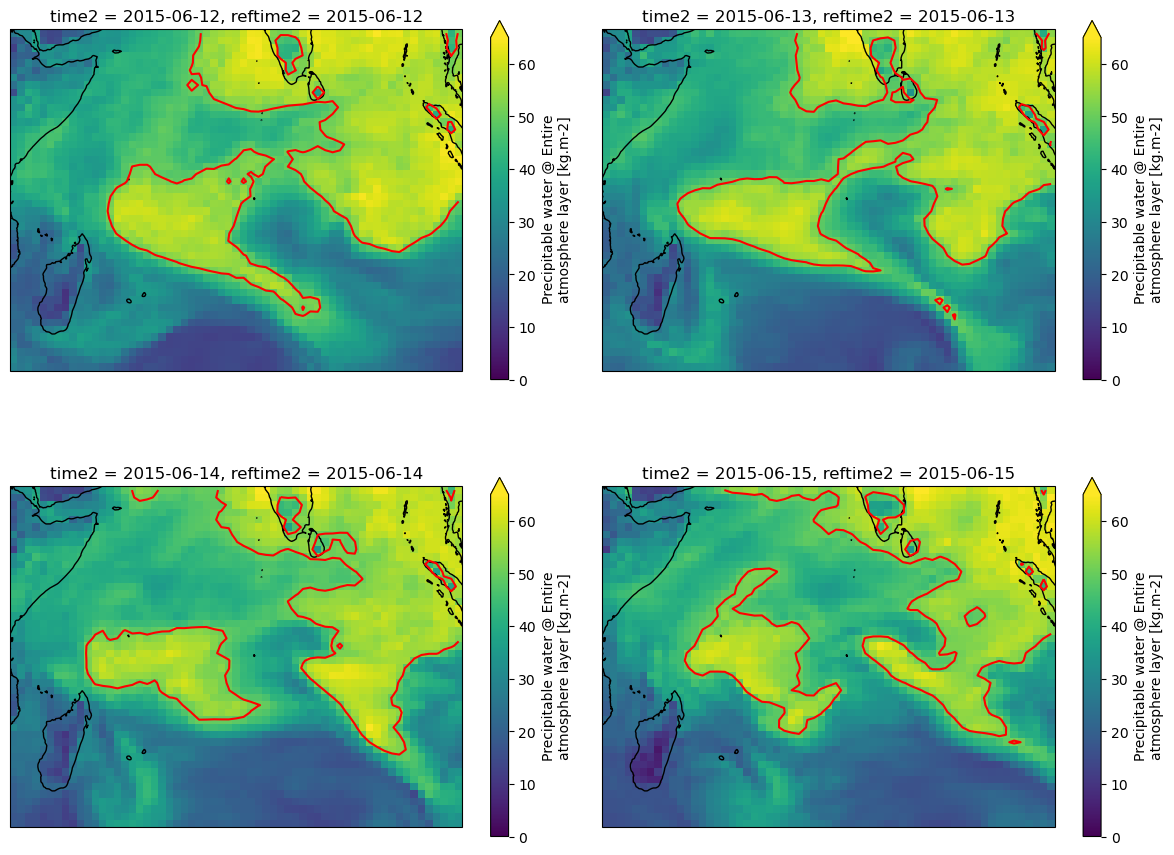

In [136]:
# Make a plot of a few GFS analysis fields 

# Create figure with Cartopy projection
fig, axes = plt.subplots(2, 2, subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 10))

for itime in range(4): 
    ax = axes.flat[itime]
    gfs_agg.sel(lat = slice(15,-30), lon=slice(40,100), time2=slice("2015-06-12 00:00","2015-06-15 00:00",4) ) \
        ['Precipitable_water_entire_atmosphere_single_layer'][itime].plot(ax=ax, vmin=0, vmax=65, cbar_kwargs={'shrink': 0.7})
    gfs_agg.sel(lat = slice(15,-30), lon=slice(40,100), time2=slice("2015-06-12 00:00","2015-06-15 00:00",4) ) \
        ['Precipitable_water_entire_atmosphere_single_layer'][itime].plot.contour(ax=ax, levels=[50], colors='red')
    ax.coastlines()

plt.tight_layout()

# Part 2: a leadtime ensemble for given verification time 

In [38]:
# Open a single file, arbitrary date, use it to decide on desired fields besides the obvious one of PW 

ds = xr.open_dataset('https://tds.gdex.ucar.edu/thredds/dodsC/files/g/d084001/2020/20200301/gfs.0p25.2020030100.f012.grib2')
ds

<xarray.Dataset> Size: 2GB
Dimensions:                                                                   (
                                                                               lat: 721,
                                                                               lon: 1440,
                                                                               time: 1,
                                                                               time_bounds_1: 2,
                                                                               time1: 1,
                                                                               ...
                                                                               height_above_ground3: 1,
                                                                               height_above_ground4: 2,
                                                                               potential_vorticity_surface: 2,
                                                                               sigma: 1,
                                                                               isobaric6: 19,
                                                                               isobaric7: 24)
Coordinates: (12/31)
  * lat                                                                       (lat) float32 3kB ...
  * lon                                                                       (lon) float32 6kB ...
    reftime                                                                   datetime64[ns] 8B ...
  * time                                                                      (time) datetime64[ns] 8B ...
  * time1                                                                     (time1) datetime64[ns] 8B ...
  * time2                                                                     (time2) datetime64[ns] 16B ...
    ...                                                                        ...
  * height_above_ground3                                                      (height_above_ground3) float32 4B ...
  * height_above_ground4                                                      (height_above_ground4) float32 8B ...
  * potential_vorticity_surface                                               (potential_vorticity_surface) float32 8B ...
  * sigma                                                                     (sigma) float32 4B ...
  * isobaric6                                                                 (isobaric6) float32 76B ...
  * isobaric7                                                                 (isobaric7) float32 96B ...
Dimensions without coordinates: time_bounds_1, time2_bounds_1,
                                height_above_ground_layer_bounds_1,
                                depth_below_surface_layer_bounds_1,
                                pressure_difference_layer_bounds_1,
                                pressure_difference_layer1_bounds_1,
                                height_above_ground_layer1_bounds_1,
                                pressure_difference_layer2_bounds_1,
                                sigma_layer_bounds_1
Data variables: (12/167)
    LatLon_Projection                                                         int32 4B ...
    time_bounds                                                               (time, time_bounds_1) datetime64[ns] 16B ...
    time2_bounds                                                              (time2, time2_bounds_1) datetime64[ns] 32B ...
    height_above_ground_layer_bounds                                          (height_above_ground_layer, height_above_ground_layer_bounds_1) float32 8B ...
    depth_below_surface_layer_bounds                                          (depth_below_surface_layer, depth_below_surface_layer_bounds_1) float32 32B ...
    pressure_difference_layer_bounds                                          (pressure_difference_layer, pressure_difference_layer_bounds_1) float32 16B ...
 

In [43]:
list(ds.data_vars)

['LatLon_Projection',
 'time_bounds',
 'time2_bounds',
 'height_above_ground_layer_bounds',
 'depth_below_surface_layer_bounds',
 'pressure_difference_layer_bounds',
 'pressure_difference_layer1_bounds',
 'height_above_ground_layer1_bounds',
 'pressure_difference_layer2_bounds',
 'sigma_layer_bounds',
 'Absolute_vorticity_isobaric',
 'Albedo_surface_6_Hour_Average',
 'Apparent_temperature_height_above_ground',
 'Cloud_mixing_ratio_isobaric',
 'Cloud_mixing_ratio_hybrid',
 'Cloud_water_entire_atmosphere_single_layer',
 'Convective_available_potential_energy_surface',
 'Convective_available_potential_energy_pressure_difference_layer',
 'Convective_inhibition_surface',
 'Convective_inhibition_pressure_difference_layer',
 'Convective_precipitation_surface_Mixed_intervals_Accumulation',
 'Convective_precipitation_rate_surface',
 'Dewpoint_temperature_height_above_ground',
 'Geopotential_height_potential_vorticity_surface',
 'Geopotential_height_surface',
 'Geopotential_height_highest_tropos

In [83]:
vars_to_keep = [ \
 'Cloud_mixing_ratio_isobaric',
 'Cloud_water_entire_atmosphere_single_layer',
 'Convective_available_potential_energy_pressure_difference_layer',
 'Precipitable_water_entire_atmosphere_single_layer',
 'Pressure_reduced_to_MSL_msl',
 'Relative_humidity_isobaric',
 'Relative_humidity_entire_atmosphere_single_layer',
 'Specific_humidity_pressure_difference_layer',
 'Temperature_isobaric',
 'Convective_Precipitation_Rate_surface_6_Hour_Average',
 'MSLP_Eta_model_reduction_msl',
 'Planetary_Boundary_Layer_Height_surface',
 'Upward_Short-Wave_Radiation_Flux_atmosphere_top_6_Hour_Average',
 'Upward_Long-Wave_Radp_Flux_atmosphere_top_6_Hour_Average',
 'Vertical_velocity_pressure_isobaric',
 'u-component_of_wind_isobaric',
 'v-component_of_wind_isobaric' ]

# Okay, open a set of leadtimes for selected forecast fields

lead_hours = [12, 24, 36, 48, 60, 72, 84, 96]


In [85]:
import xarray as xr
import pandas as pd
import time
import multiprocessing
from concurrent.futures import ProcessPoolExecutor, as_completed

# --------------------------------------------------
# Settings
# --------------------------------------------------
verification = "2015-06-15 00:00"

verification_time = pd.Timestamp(verification)  # Lake of 2015-06-11-15
lead_hours = [12, 24, 36, 48, 60, 72, 84, 96]
run_hours = [0, 6, 12, 18]

base_url = (
    "https://tds.gdex.ucar.edu/thredds/dodsC/files/g/d084001/"
    "{year}/{year}{month:02d}{day:02d}/"
    "gfs.0p25.{year}{month:02d}{day:02d}{hour:02d}.f{lead:03d}.grib2"
)

def gfs_url(run_time, lead):
    return base_url.format(
        year=run_time.year, month=run_time.month,
        day=run_time.day, hour=run_time.hour, lead=lead,
    )

def fetch_one(args):
    run_time, lead, vars_to_keep = args
    import xarray as xr
    url = gfs_url(run_time, lead)
    ds = xr.open_dataset(url, decode_times=False, decode_coords=False)
    ds = ds[vars_to_keep]
    ds = ds.drop_vars(["time", "time1", "time2", "pressure_difference_layer"], errors="ignore")
    ds = ds.assign_coords(leadtime=lead).expand_dims("leadtime")
    ds.load()
    return lead, ds

# --------------------------------------------------
# Build pairs
# --------------------------------------------------
pairs = [
    (verification_time - pd.Timedelta(hours=lead), lead)
    for lead in lead_hours
    if (verification_time - pd.Timedelta(hours=lead)).hour in run_hours
]
print(f"Verification time: {verification_time}  |  {len(pairs)} datasets\n")

# --------------------------------------------------
# Fetch + combine
# --------------------------------------------------
t0 = time.time()
datasets = {}

with ProcessPoolExecutor(max_workers=min(6, len(pairs))) as executor:
    futures = {
        executor.submit(fetch_one, (run_time, lead, vars_to_keep)): (run_time, lead)
        for run_time, lead in pairs
    }
    for future in as_completed(futures):
        run_time, lead = futures[future]
        try:
            lead_val, ds = future.result()
            datasets[lead_val] = ds
            print(f"  ✓ lead={lead:3d}h  ({run_time})  |  elapsed {time.time()-t0:5.1f}s")
        except Exception as e:
            print(f"  ✗ lead={lead:3d}h  ({run_time})  FAILED: {e}")

ds_fcst = xr.concat([datasets[l] for l in sorted(datasets)], dim="leadtime")
print(f"\nDone in {time.time()-t0:.1f}s")
ds_fcst

Verification time: 2015-06-15 00:00:00  |  8 datasets

  ✓ lead= 36h  (2015-06-13 12:00:00)  |  elapsed  85.9s
  ✓ lead= 24h  (2015-06-14 00:00:00)  |  elapsed 113.0s
  ✓ lead= 48h  (2015-06-13 00:00:00)  |  elapsed 115.8s
  ✓ lead= 12h  (2015-06-14 12:00:00)  |  elapsed 119.5s
  ✓ lead= 72h  (2015-06-12 00:00:00)  |  elapsed 120.2s
  ✓ lead= 60h  (2015-06-12 12:00:00)  |  elapsed 146.5s
  ✓ lead= 84h  (2015-06-11 12:00:00)  |  elapsed 150.2s
  ✓ lead= 96h  (2015-06-11 00:00:00)  |  elapsed 172.7s

Done in 174.9s


<xarray.Dataset> Size: 5GB
Dimensions:                                                          (
                                                                      leadtime: 8,
                                                                      time: 1,
                                                                      isobaric3: 21,
                                                                      lat: 721,
                                                                      lon: 1440,
                                                                      time1: 1,
                                                                      pressure_difference_layer2: 2,
                                                                      isobaric2: 26,
                                                                      pressure_difference_layer1: 1)
Coordinates:
  * lat                                                              (lat) float32 3kB ...
  * lon                                                              (lon) float32 6kB ...
  * isobaric2                                                        (isobaric2) float32 104B ...
  * pressure_difference_layer1                                       (pressure_difference_layer1) float32 4B ...
  * isobaric3                                                        (isobaric3) float32 84B ...
  * pressure_difference_layer2                                       (pressure_difference_layer2) float32 8B ...
  * leadtime                                                         (leadtime) int64 64B ...
Dimensions without coordinates: time, time1
Data variables: (12/17)
    Cloud_mixing_ratio_isobaric                                      (leadtime, time, isobaric3, lat, lon, time1) float32 698MB ...
    Cloud_water_entire_atmosphere_single_layer                       (leadtime, time, lat, lon, time1) float32 33MB ...
    Convective_available_potential_energy_pressure_difference_layer  (leadtime, time, pressure_difference_layer2, lat, lon, time1) float32 66MB ...
    Precipitable_water_entire_atmosphere_single_layer                (leadtime, time, lat, lon, time1) float32 33MB ...
    Pressure_reduced_to_MSL_msl                                      (leadtime, time, lat, lon, time1) float32 33MB ...
    Relative_humidity_isobaric                                       (leadtime, time, isobaric2, lat, lon, time1) float32 864MB ...
    ...                                                               ...
    Planetary_Boundary_Layer_Height_surface                          (leadtime, time, lat, lon, time1) float32 33MB ...
    Upward_Short-Wave_Radiation_Flux_atmosphere_top_6_Hour_Average   (leadtime, time1, lat, lon, time) float32 33MB ...
    Upward_Long-Wave_Radp_Flux_atmosphere_top_6_Hour_Average         (leadtime, time1, lat, lon, time) float32 33MB ...
    Vertical_velocity_pressure_isobaric                              (leadtime, time, isobaric3, lat, lon, time1) float32 698MB ...
    u-component_of_wind_isobaric                                     (leadtime, time, isobaric2, lat, lon, time1) float32 864MB ...
    v-component_of_wind_isobaric                                     (leadtime, time, isobaric2, lat, lon, time1) float32 864MB ...
Attributes:
    Originating_or_generating_Center:                                        ...
    Originating_or_generating_Subcenter:                                     ...
    GRIB_table_version:                                                      ...
    Type_of_generating_process:                                              ...
    Analysis_or_forecast_generating_process_identifier_defined_by_originating...
    file_format:                                                             ...
    Conventions:                                                             ...
    history:                                                                 ...
    featureType:                                                             ...

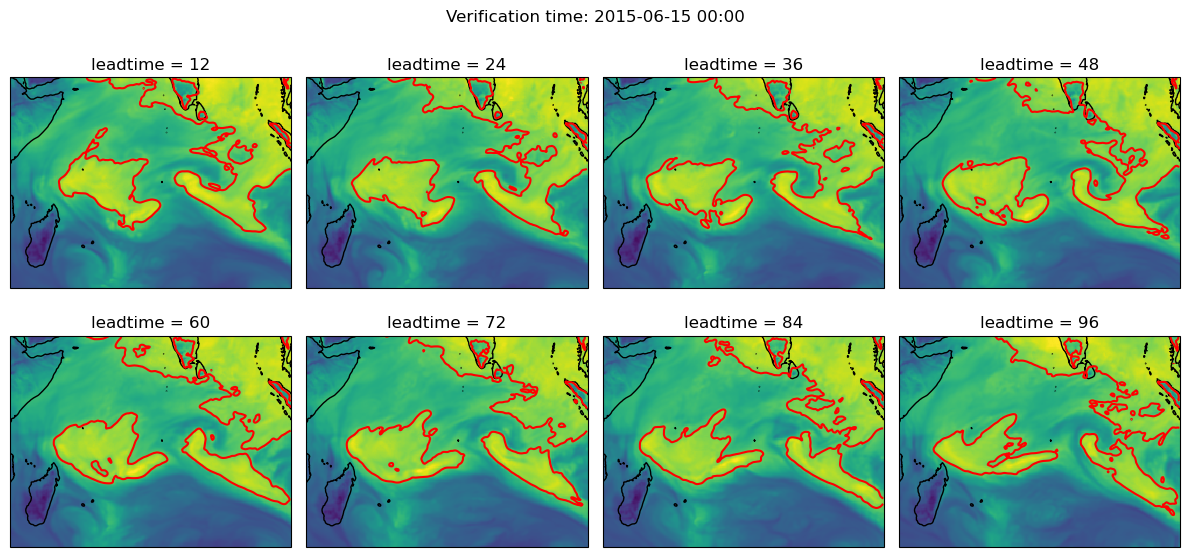

In [137]:
# Plots of PW itself as a function of leadtime 

# Create figure with Cartopy projection
fig, axes = plt.subplots(2, 4, subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 6))
plt.suptitle('Verification time: '+ verification)

for ilead in range(len(ds_fcst.leadtime)):
    ax = axes.flat[ilead]
    ds_fcst.sel(lat=slice(15, -30), lon=slice(40, 100)) \
        ['Precipitable_water_entire_atmosphere_single_layer'][ilead].plot(
        ax=ax, transform=ccrs.PlateCarree(), add_colorbar=False, vmin=0, vmax=65)
    ds_fcst.sel(lat=slice(15, -30), lon=slice(40, 100)) \
        ['Precipitable_water_entire_atmosphere_single_layer'][ilead].squeeze().plot.contour(levels=[50], ax=ax, colors='red')
    ax.coastlines()

plt.tight_layout()   